# Simple Crossover

- Test out codes for [Momentum-Based Strategy Optimization with Grid Search on Backtrader](https://medium.com/funny-ai-quant/momentum-based-strategy-optimization-with-grid-search-on-backtrader-8c0d6cd1cc36)


In [1]:
import backtrader as bt
from backtrader.feeds import PandasData
from datetime import datetime
import os
import sys
import pandas as pd
from pathlib import Path
import random
from collections import deque
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product


repo_dir = Path.cwd().as_posix()

if repo_dir not in sys.path:
    sys.path.append(repo_dir)

%load_ext autoreload
%autoreload 2
%matplotlib inline

from src import utils

In [23]:
class SMACrossStrategy(bt.Strategy):
    params = (
        ("short_window", 5),
        ("long_window", 20),
        ("trade_size", 0.01),
    )

    def __init__(self):
        self.short_ma = bt.indicators.SimpleMovingAverage(
            self.data.close, period=self.params.short_window
        )
        self.long_ma = bt.indicators.SimpleMovingAverage(
            self.data.close, period=self.params.long_window
        )
        self.crossover = bt.indicators.CrossOver(self.short_ma, self.long_ma)

        self.trades = []
        self.trade_returns = []
        self.buys = []
        self.sells = []

        self.equity = []
        self.max_drawdown = 0
        self.peak_equity = 0
        self.results = []

    def next(self):
        if self.crossover > 0:
            if self.position.size < 0:
                self.close()
            self.buy(size=self.calculate_trade_size())
            self.buys.append(self.data.datetime.date(0))
        elif self.crossover < 0:
            if self.position.size > 0:
                self.close()
            self.sell(size=self.calculate_trade_size())
            self.sells.append(self.data.datetime.date(0))

        current_equity = self.broker.getvalue()
        self.equity.append(current_equity)
        self.peak_equity = max(self.peak_equity, current_equity)
        drawdown = (self.peak_equity - current_equity) / self.peak_equity
        self.max_drawdown = max(self.max_drawdown, drawdown)

    def calculate_trade_size(self):
        trade_cash = self.broker.getvalue() * self.params.trade_size
        return self.broker.getposition(self.data).size or int(
            trade_cash / self.data.close[0]
        )

    def notify_trade(self, trade):
        if trade.isclosed:
            self.trades.append(trade)
            returns = trade.pnlcomm / trade.price
            self.trade_returns.append(returns)

    def stop(self):
        short = self.params.short_window
        long = self.params.long_window
        trade_size = self.params.trade_size
        sharpe = self.analyzers.sharpe.get_analysis()
        # total_return = self.analyzers.returns.get_analysis()["rtot"]
        # annual_return = self.analyzers.returns.get_analysis()["rnorm"]
        # max_drawdown = self.analyzers.drawdown.get_analysis()["max"]["drawdown"]

        print(f"sharpe : {sharpe}")

        self.results.append(
            {
                "short_window": short,
                "long_window": long,
                "trade_size": trade_size,
                "total_trades": len(self.trades),
                "sharpe_ratio": sharpe,
                # "total_return": total_return,
                # "max_drawdown": max_drawdown,
                # "annual_return": annual_return,
            }
        )

        # print(
        #     f"Processed: Short={short}, Long={long}, Trade Size={trade_size}, Sharpe={sharpe}, Total Return={total_return}"
        # )

        print(
            f"Processed: Short={short}, Long={long}, Trade Size={trade_size}, Sharpe={sharpe}"
        )

In [6]:
yf.download("AAPL", start="2024-01-01", end="2024-12-31", multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,184.532074,187.315366,182.792518,186.033057,82488700
2024-01-03,183.150375,184.770652,182.335262,183.120556,58414500
2024-01-04,180.824371,181.997322,179.800520,181.062929,71983600
2024-01-05,180.098694,181.669266,179.094727,180.903872,62303300
2024-01-08,184.452560,184.492330,180.416793,181.003268,59144500
...,...,...,...,...,...
2024-12-23,254.989655,255.369227,253.171646,254.490204,40858800
2024-12-24,257.916443,257.926411,255.009620,255.209412,23234700
2024-12-26,258.735504,259.814335,257.347047,257.906429,27237100


In [8]:
class BacktestingEngine:
    def __init__(
        self, ticker, start_date, end_date, initial_cash=100000.0, commission=0.001
    ):
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date
        self.initial_cash = initial_cash
        self.commission = commission
        self.data = self.download_data()
        self.results = None

    def download_data(self):
        try:
            data = yf.download(
                self.ticker,
                start=self.start_date,
                end=self.end_date,
                multi_level_index=False,
            )
            if data.empty:
                raise ValueError("No data available for the specified date range")
            return data
        except Exception as e:
            print(f"Error downloading data: {e}")
            return None

    def run_backtest(self, short_window, long_window, trade_size):
        if self.data is None:
            print("No data available for backtesting")
            return None

        cerebro = bt.Cerebro()
        cerebro.broker.setcash(self.initial_cash)
        cerebro.broker.setcommission(commission=self.commission)
        cerebro.addstrategy(
            SMACrossStrategy,
            short_window=int(short_window),
            long_window=int(long_window),
            trade_size=trade_size,
        )
        cerebro.adddata(bt.feeds.PandasData(dataname=self.data))
        cerebro.addanalyzer(bt.analyzers.DrawDown, _name="drawdown")
        cerebro.addanalyzer(bt.analyzers.Returns, _name="returns")
        cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name="trades")
        cerebro.addanalyzer(bt.analyzers.SharpeRatio_A, _name="sharpe")

        self.results = cerebro.run()
        return self.results[0]

    def analyze_results(
        self,
        strategy,
        print_details=True,
        print_annual_metrics=True,
        print_trades_table=False,
    ):
        if strategy is None:
            print("No strategy results to analyze")
            return None

        max_drawdown = strategy.max_drawdown
        total_return = strategy.broker.getvalue() / self.initial_cash - 1
        total_return_cash = strategy.broker.getvalue() - self.initial_cash
        trade_returns = np.array(strategy.trade_returns)
        annual_metrics = self.calculate_annualized_metrics(strategy)

        if print_details:
            print("\n" + "=" * 50)
            print(f"Backtest Results for {self.ticker}:")
            print(f"\nDetailed Analysis:")
            print(f"Initial cash: {self.initial_cash}")
            print(f"Final cash: {strategy.broker.getvalue():.2f}")
            print(f"Total return (cash): {total_return_cash:.2f}")
            print(f"Total return (%): {total_return:.2%}")
            print(f"Max drawdown: {max_drawdown:.2%}")
            print(f"Number of trades: {len(strategy.trades)}")
            print(f"trade_returns : {trade_returns}")

        if print_annual_metrics:
            print("\n" + "=" * 50)
            print("\nAnnualized Metrics:")
            print(f"Annual return: {annual_metrics['Annual Return']:.2%}")
            print(f"Annual volatility: {annual_metrics['Annual Volatility']:.2%}")
            print(f"Sharpe ratio: {annual_metrics['Sharpe Ratio']:.4f}")

        if print_trades_table:
            trades = []
            for trade in strategy.trades:
                trades.append(
                    [trade.ref, trade.dtopen, trade.dtclose, trade.pnl, trade.pnlcomm]
                )
            trades_df = pd.DataFrame(
                trades,
                columns=[
                    "Trade ID",
                    "Open Date",
                    "Close Date",
                    "Profit/Loss",
                    "PnL (incl. commission)",
                ],
            )
            print("\n" + "=" * 50)
            print("\nTrades:")
            # print(tabulate(trades_df, headers='keys', tablefmt='psql'))
            print(trades_df)

        return {
            "sharpe_ratio": annual_metrics["Sharpe Ratio"],
            "annual_return": annual_metrics["Annual Return"],
            "annual_volatility": annual_metrics["Annual Volatility"],
            "max_drawdown": max_drawdown,
            "total_return": total_return,
        }

    def calculate_annualized_metrics(
        self, strategy, risk_free_rate=0.00
    ) -> dict[str, float]:
        first_date = self.data.index[0].to_pydatetime().date()
        last_date = self.data.index[-1].to_pydatetime().date()
        total_days = (last_date - first_date).days
        annual_factor = 252 / total_days

        daily_returns = pd.Series(strategy.equity).pct_change().dropna()

        if len(daily_returns) > 0:
            total_return = (strategy.broker.getvalue() / self.initial_cash) - 1
            annual_return = (1 + total_return) ** annual_factor - 1

            annual_volatility = daily_returns.std() * np.sqrt(252)

            if annual_volatility != 0:
                sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility
            else:
                sharpe_ratio = 0
        else:
            annual_return = annual_volatility = sharpe_ratio = 0

        return {
            "Annual Return": annual_return,
            "Annual Volatility": annual_volatility,
            "Sharpe Ratio": sharpe_ratio,
        }

    def plot_results(self, short_window, long_window, trade_size):
        if self.data is None:
            print("No data available for plotting")
            return

        strategy = self.run_backtest(short_window, long_window, trade_size)
        if strategy is None:
            return

        fig, ax = plt.subplots(figsize=(15, 8))

        ax.plot(self.data.index, self.data["Close"], label="Close Price", alpha=0.7)
        ax.plot(
            self.data.index,
            self.data["Close"].rolling(window=short_window).mean(),
            label=f"{short_window}-day SMA",
            alpha=0.7,
        )
        ax.plot(
            self.data.index,
            self.data["Close"].rolling(window=long_window).mean(),
            label=f"{long_window}-day SMA",
            alpha=0.7,
        )

        ax.scatter(
            strategy.buys,
            self.data.loc[strategy.buys]["Close"],
            marker="^",
            color="g",
            label="Buy Signal",
            alpha=1,
            s=100,
        )
        ax.scatter(
            strategy.sells,
            self.data.loc[strategy.sells]["Close"],
            marker="v",
            color="r",
            label="Sell Signal",
            alpha=1,
            s=100,
        )

        ax.set_title(
            f"SMA Crossover Strategy: {self.ticker}\n{self.start_date} to {self.end_date}"
        )
        ax.set_xlabel("Date")
        ax.set_ylabel("Price")
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.xticks(rotation=45)

        analysis = self.analyze_results(strategy)

        performance_text = (
            f"Sharpe Ratio: {analysis['sharpe_ratio']:.4f}\n"
            f"Annual Return: {analysis['annual_return']:.2%}\n"
            f"Annual Volatility: {analysis['annual_volatility']:.2%}\n"
            f"Max Drawdown: {analysis['max_drawdown']:.2%}\n"
            f"Total Return: {analysis['total_return']:.2%}"
        )
        plt.text(
            0.05,
            0.95,
            performance_text,
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
        )

        plt.tight_layout()
        plt.show()

    def optimize_parameters(
        self, short_window_range, long_window_range, trade_size_range
    ):
        results = []
        for short, long, size in product(
            short_window_range, long_window_range, trade_size_range
        ):
            if short >= long:
                continue
            strategy = self.run_backtest(short, long, size)
            if strategy is None:
                continue
            analysis = self.analyze_results(
                strategy,
                print_details=False,
                print_annual_metrics=False,
                print_trades_table=False,
            )
            if analysis is None:
                continue
            results.append(
                {
                    "short_window": short,
                    "long_window": long,
                    "trade_size": size,
                    "total_trades": len(strategy.trades),
                    "sharpe_ratio": analysis["sharpe_ratio"],
                    "total_return": analysis["total_return"],
                    "max_drawdown": analysis["max_drawdown"],
                    "annual_return": analysis["annual_return"],
                    "annual_volatility": analysis["annual_volatility"],
                }
            )
            print(
                f"Processed: Short={short}, Long={long}, Trade Size={size:.2%}, Sharpe={analysis['sharpe_ratio']:.4f}, Total Return={analysis['total_return']:.2%}"
            )

        results_df = pd.DataFrame(results)
        results_df = results_df.sort_values(
            "sharpe_ratio", ascending=False
        ).reset_index(drop=True)

        return results_df

    def optimize_parameters_bt(
        self, short_window_range, long_window_range, trade_size_range
    ):
        if self.data is None:
            print("No data available for backtesting")
            return None

        cerebro = bt.Cerebro()
        cerebro.broker.setcash(self.initial_cash)
        cerebro.broker.setcommission(commission=self.commission)
        cerebro.optstrategy(
            SMACrossStrategy,
            short_window=short_window_range,
            long_window=long_window_range,
            trade_size=trade_size_range,
        )
        cerebro.adddata(bt.feeds.PandasData(dataname=self.data))
        cerebro.addanalyzer(bt.analyzers.DrawDown, _name="drawdown")
        cerebro.addanalyzer(bt.analyzers.Returns, _name="returns")
        cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name="trades")
        cerebro.addanalyzer(bt.analyzers.SharpeRatio_A, _name="sharpe")

        self.strategy = cerebro.run()
        print(f"self.strategy : {self.strategy}")
        print(f"self.strategy[0] : {self.strategy[0]}")
        print(f"len(self.strategy) : {len(self.strategy)}")

        return self.strategy[0]

    def display_optimization_results(self, results_df, top_n=10):
        print(f"\nTop {top_n} Optimization Results:")
        print(results_df.head(top_n).to_string(index=False))

        pivot_df = results_df.pivot(
            index="short_window", columns="long_window", values="sharpe_ratio"
        )

        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".2f")
        plt.title("Sharpe Ratio Heatmap")
        plt.xlabel("Long Window")
        plt.ylabel("Short Window")
        plt.show()

        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection="3d")
        X, Y = np.meshgrid(pivot_df.columns, pivot_df.index)
        surf = ax.plot_surface(X, Y, pivot_df.values, cmap="viridis")
        ax.set_xlabel("Long Window")
        ax.set_ylabel("Short Window")
        ax.set_zlabel("Sharpe Ratio")
        ax.set_title("3D Surface Plot of Sharpe Ratio")
        fig.colorbar(surf, shrink=0.5, aspect=5)
        plt.show()

## cerebro.run()

- Output of cerebro.run is list of strategies.
- Access result of analyzers via '.analyzers.get_analysis()'


In [24]:
btesting = BacktestingEngine("AAPL", start_date="2010-01-01", end_date="2025-03-04")
result = btesting.run_backtest(short_window=5, long_window=20, trade_size=0.01)

drawdown_dict = result.analyzers.drawdown.get_analysis()
drawdown_dict.keys()

[*********************100%***********************]  1 of 1 completed


sharpe : OrderedDict()
Processed: Short=5, Long=20, Trade Size=0.01, Sharpe=OrderedDict()


odict_keys(['len', 'drawdown', 'moneydown', 'max'])

In [10]:
result.analyzers.drawdown.get_analysis()

AutoOrderedDict([('len', 157),
                 ('drawdown', 3.6467866967985176),
                 ('moneydown', 4751.179981134424),
                 ('max',
                  AutoOrderedDict([('len', 1533),
                                   ('drawdown', 6.392076526763497),
                                   ('moneydown', 8327.853685135866)]))])

In [11]:
result.analyzers.returns.get_analysis()

OrderedDict([('rtot', 0.22739714010083356),
             ('ravg', 5.962169378626994e-05),
             ('rnorm', 0.015138104550143913),
             ('rnorm100', 1.5138104550143912)])

In [14]:
result.analyzers.returns.get_analysis()["rtot"]

0.22739714010083356

In [12]:
result.analyzers.trades.get_analysis()

AutoOrderedDict([('total',
                  AutoOrderedDict([('total', 201),
                                   ('open', 1),
                                   ('closed', 200)])),
                 ('streak',
                  AutoOrderedDict([('won',
                                    AutoOrderedDict([('current', 0),
                                                     ('longest', 3)])),
                                   ('lost',
                                    AutoOrderedDict([('current', 2),
                                                     ('longest', 9)]))])),
                 ('pnl',
                  AutoOrderedDict([('gross',
                                    AutoOrderedDict([('total',
                                                      29675.76284172346),
                                                     ('average',
                                                      148.37881420861729)])),
                                   ('net',
                          

In [13]:
a = result.analyzers.sharpe.get_analysis()
a["sharperatio"]

0.20924972170607653

## analyze_results


In [16]:
btesting.analyze_results(result, print_trades_table=True)


Backtest Results for AAPL:

Detailed Analysis:
Initial cash: 100000.0
Final cash: 125532.87
Total return (cash): 25532.87
Total return (%): 25.53%
Max drawdown: 6.39%
Number of trades: 200
trade_returns : [ 39.17858924  -9.7022077  -10.42920532  -8.8395033   -6.98567906
  -7.13083224  -6.11857615  -3.58326393  28.11859232  -7.16276247
  16.1318852   -7.36982922  -3.46304266   0.85268309  -6.1872414
  -7.86369322 -10.34482363  -5.85624705  -5.06866121  -1.04226538
  12.69271596 -12.57327052  -6.10079423 -21.00143447  -7.98489627
   3.55934717  -2.31070237  -4.10865009  74.94274409   2.43392364
   2.20495622  -5.12225586  -5.80037473 -12.39873773  14.7345926
  18.97493241 -18.26647765  -4.07101458  -5.20065279  15.76296337
  -6.62602653  -3.3134974   -8.80239941  -4.37754935  -1.58487383
  -5.04141315  -5.77674779   5.75270209  19.97323601  -5.68212124
  13.92360307  -1.51174453  -2.52453959  -5.63351943   9.35282475
   0.88007475  -3.51279606   0.53905066 -14.02913854 -11.37442697
  -3

{'sharpe_ratio': np.float64(0.28139976511522646),
 'annual_return': 0.010403055998351896,
 'annual_volatility': np.float64(0.03696895764675601),
 'max_drawdown': 0.06392072610579289,
 'total_return': 0.2553287419042183}

## plot_results



Backtest Results for AAPL:

Detailed Analysis:
Initial cash: 100000.0
Final cash: 125532.87
Total return (cash): 25532.87
Total return (%): 25.53%
Max drawdown: 6.39%
Number of trades: 200
trade_returns : [ 39.17858924  -9.7022077  -10.42920532  -8.8395033   -6.98567906
  -7.13083224  -6.11857615  -3.58326393  28.11859232  -7.16276247
  16.1318852   -7.36982922  -3.46304266   0.85268309  -6.1872414
  -7.86369322 -10.34482363  -5.85624705  -5.06866121  -1.04226538
  12.69271596 -12.57327052  -6.10079423 -21.00143447  -7.98489627
   3.55934717  -2.31070237  -4.10865009  74.94274409   2.43392364
   2.20495622  -5.12225586  -5.80037473 -12.39873773  14.7345926
  18.97493241 -18.26647765  -4.07101458  -5.20065279  15.76296337
  -6.62602653  -3.3134974   -8.80239941  -4.37754935  -1.58487383
  -5.04141315  -5.77674779   5.75270209  19.97323601  -5.68212124
  13.92360307  -1.51174453  -2.52453959  -5.63351943   9.35282475
   0.88007475  -3.51279606   0.53905066 -14.02913854 -11.37442697
  -3

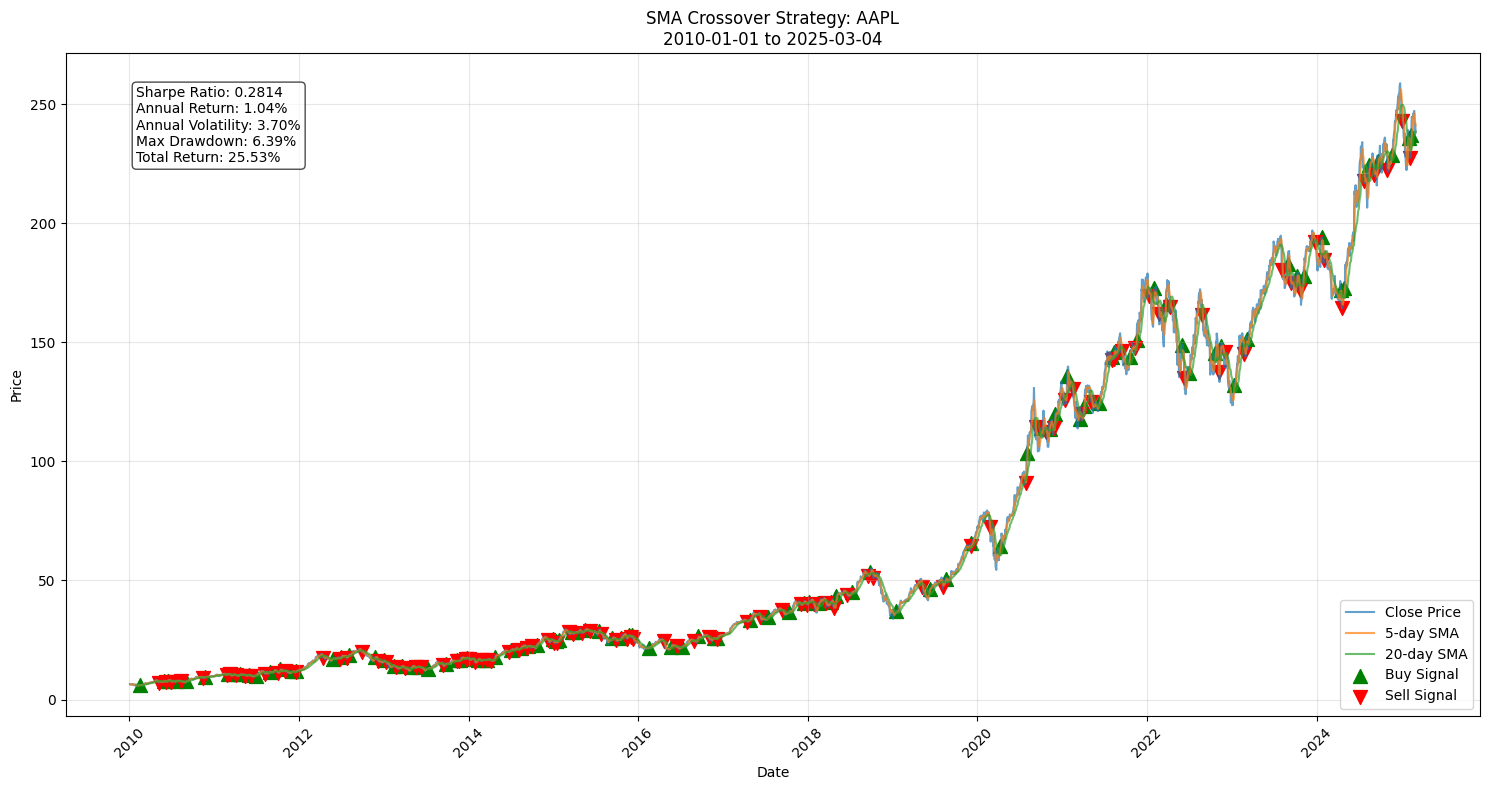

In [28]:
btesting.plot_results(short_window=5, long_window=20, trade_size=0.01)

## Optimize


In [36]:
btesting.optimize_parameters(
    range(1, 15), range(15, 31), np.linspace(0.001, 0.01, num=10)
)

Processed: Short=1, Long=15, Trade Size=0.10%, Sharpe=0.1670, Total Return=1.52%
Processed: Short=1, Long=15, Trade Size=0.20%, Sharpe=0.1669, Total Return=3.14%
Processed: Short=1, Long=15, Trade Size=0.30%, Sharpe=0.1668, Total Return=4.76%
Processed: Short=1, Long=15, Trade Size=0.40%, Sharpe=0.1667, Total Return=6.29%
Processed: Short=1, Long=15, Trade Size=0.50%, Sharpe=0.1666, Total Return=7.91%
Processed: Short=1, Long=15, Trade Size=0.60%, Sharpe=0.1665, Total Return=9.53%
Processed: Short=1, Long=15, Trade Size=0.70%, Sharpe=0.1663, Total Return=11.15%
Processed: Short=1, Long=15, Trade Size=0.80%, Sharpe=0.1662, Total Return=12.67%
Processed: Short=1, Long=15, Trade Size=0.90%, Sharpe=0.1661, Total Return=14.29%
Processed: Short=1, Long=15, Trade Size=1.00%, Sharpe=0.1660, Total Return=15.91%
Processed: Short=1, Long=16, Trade Size=0.10%, Sharpe=0.2082, Total Return=1.91%
Processed: Short=1, Long=16, Trade Size=0.20%, Sharpe=0.2083, Total Return=3.93%
Processed: Short=1, Long

,short_window,long_window,trade_size,total_trades,sharpe_ratio,total_return,max_drawdown,annual_return,annual_volatility
0,6,17,0.010,222,0.388915,0.360754,0.068934,0.014118,0.036301
1,6,17,0.009,222,0.388682,0.323358,0.062577,0.012833,0.033016
2,6,17,0.008,222,0.388448,0.288163,0.056444,0.011591,0.029839
3,6,17,0.007,222,0.388182,0.250768,0.049762,0.010236,0.026368
4,6,17,0.006,222,0.387915,0.215572,0.043311,0.008924,0.023006
...,...,...,...,...,...,...,...,...,...
2235,12,29,0.006,132,-0.087554,-0.046758,0.126947,-0.002177,0.024865
2236,12,29,0.007,132,-0.088359,-0.054633,0.146272,-0.002554,0.028901
2237,12,29,0.008,132,-0.089166,-0.062508,0.165068,-0.002933,0.032898
2238,12,29,0.009,132,-0.089977,-0.070383,0.183357,-0.003316,0.036855


In [25]:
btesting = BacktestingEngine("AAPL", start_date="2010-01-01", end_date="2025-03-04")
btesting.optimize_parameters_bt(
    range(1, 15), range(15, 31), np.linspace(0.001, 0.01, num=10)
)

[*********************100%***********************]  1 of 1 completed


sharpe : OrderedDict()
sharpe : OrderedDict()Processed: Short=1, Long=15, Trade Size=0.003, Sharpe=OrderedDict()

Processed: Short=1, Long=15, Trade Size=0.001, Sharpe=OrderedDict()
sharpe : OrderedDict()
Processed: Short=1, Long=15, Trade Size=0.008, Sharpe=OrderedDict()
sharpe : OrderedDict()
Processed: Short=1, Long=15, Trade Size=0.002, Sharpe=OrderedDict()
sharpe : OrderedDict()
Processed: Short=1, Long=15, Trade Size=0.004, Sharpe=OrderedDict()
sharpe : OrderedDict()
Processed: Short=1, Long=15, Trade Size=0.005, Sharpe=OrderedDict()
sharpe : OrderedDict()
Processed: Short=1, Long=15, Trade Size=0.006, Sharpe=OrderedDict()
sharpe : OrderedDict()
Processed: Short=1, Long=15, Trade Size=0.007, Sharpe=OrderedDict()
sharpe : OrderedDict()
Processed: Short=1, Long=15, Trade Size=0.009000000000000001, Sharpe=OrderedDict()
sharpe : OrderedDict()
Processed: Short=1, Long=15, Trade Size=0.01, Sharpe=OrderedDict()
sharpe : OrderedDict()
Processed: Short=1, Long=16, Trade Size=0.001, Sharpe

AttributeError: 'list' object has no attribute 'results'